In [8]:
import pandas as pd
import numpy as np

# IMPORT DATA

In [21]:
df = pd.read_csv('data/datasets/pima_indians_diabetes_with_header.csv')

In [22]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [23]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [56]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [180]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# EDA

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [70]:
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

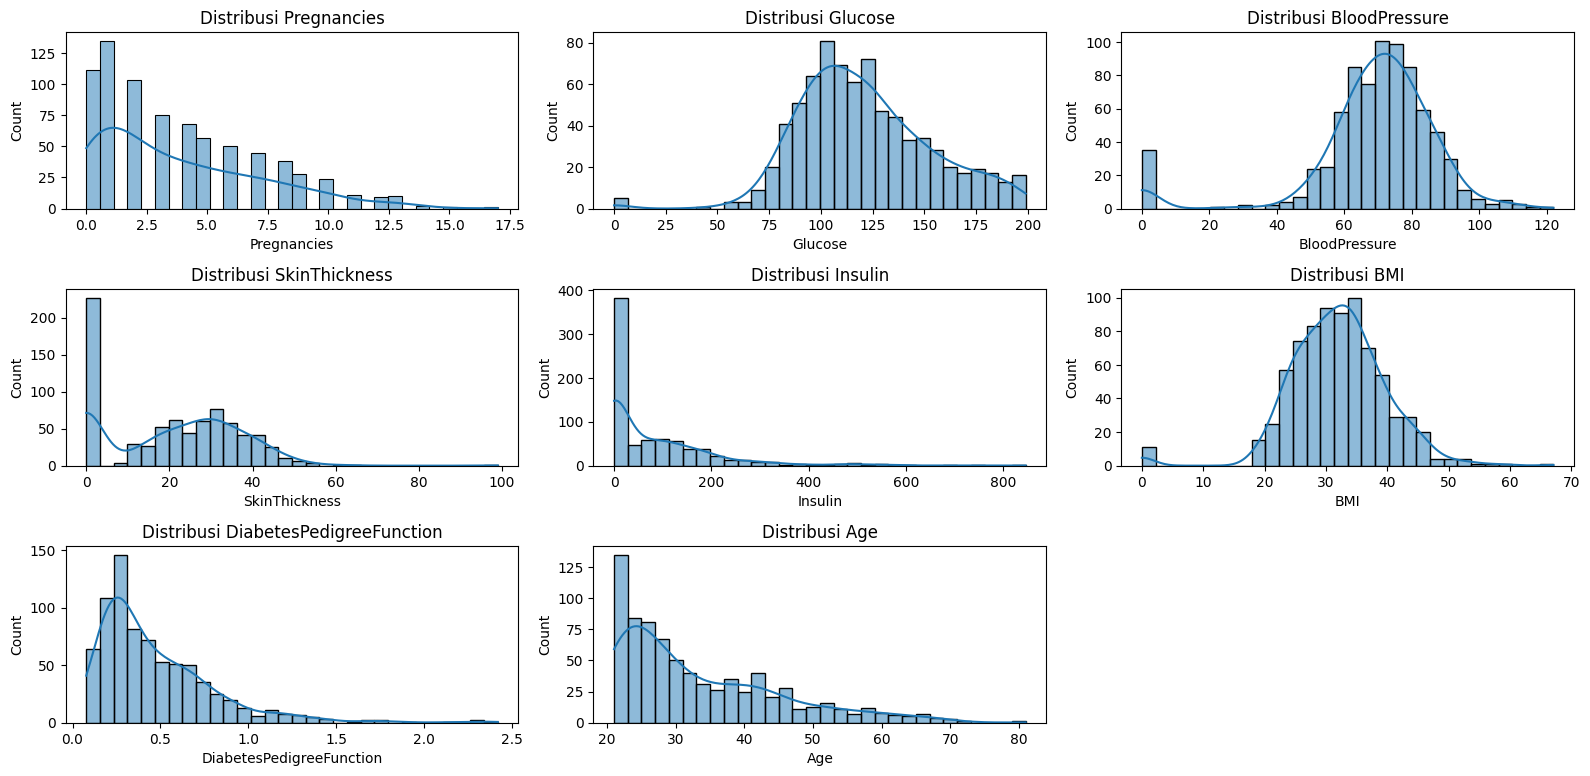

In [71]:
# Plot numerik
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribusi {col}')
    plt.tight_layout()

plt.show()

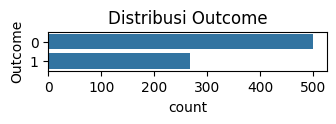

In [73]:
col = 'Outcome'
plt.subplot(5, 2, 1)
sns.countplot(data=df, y=col, order=df[col].value_counts().index[:10])  # ambil top 10 kategori
plt.title(f'Distribusi {col}')
plt.tight_layout()

plt.show()

## Feature Selection

In [192]:
from scipy.stats import ttest_ind

for i, col in enumerate(df.columns[:-1]):  # exclude 'Outcome'
    group0 = df[df['Outcome'] == 0][col]
    group1 = df[df['Outcome'] == 1][col]
    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
    print(f"{col:30} | p-value: {p_val:.4f}")


Pregnancies                    | p-value: 0.0000
Glucose                        | p-value: 0.0000
BloodPressure                  | p-value: 0.0874
SkinThickness                  | p-value: 0.0494
Insulin                        | p-value: 0.0010
BMI                            | p-value: 0.0000
DiabetesPedigreeFunction       | p-value: 0.0000
Age                            | p-value: 0.0000


# LINEAR REGRESSION

1. Tipe Target (y) adalah Kategorik

    Outcome hanya memiliki dua nilai: 0 (negatif diabetes) dan 1 (positif diabetes).

    Regresi linear hanya cocok untuk target yang kontinu (misal: harga, berat, suhu).

    Kalau dipaksakan, regresi linear bisa menghasilkan prediksi di luar [0,1], yang tidak bermakna dalam konteks klasifikasi.

2. Asumsi Error Regresi Linear Tidak Terpenuhi

    Regresi linear mengasumsikan bahwa residual/error memiliki distribusi normal dan varians konstan (homoskedastisitas).

    Dalam kasus klasifikasi, error-nya bersifat biner (benar/salah), bukan residual kontinu.

3. Hubungan X dan y Tidak Linear

    Model linear tidak mampu menangkap batas keputusan ("decision boundary") yang dibutuhkan untuk memisahkan kelas 0 dan 1.

    Untuk klasifikasi biner, model seperti logistic regression lebih cocok karena mengubah output menjadi probabilitas antara 0 dan 1 dengan fungsi sigmoid.

4. Interpretasi Koefisien Tidak Sesuai

    Dalam regresi linear, koefisien menggambarkan perubahan nilai rata-rata target.

    Dalam klasifikasi, yang kita butuhkan adalah kemungkinan atau log odds, bukan nilai numerik langsung.

# LOGISTIC REGRESSION

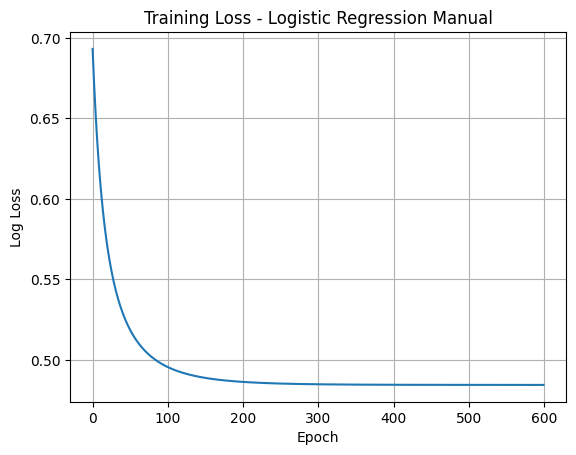

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

         0.0     0.8182    0.9000    0.8571       100
         1.0     0.7727    0.6296    0.6939        54

    accuracy                         0.8052       154
   macro avg     0.7955    0.7648    0.7755       154
weighted avg     0.8022    0.8052    0.7999       154



In [197]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# === Step 1: Scaling & split ===
X = df.drop(columns=['BloodPressure','Outcome']).values
y = df['Outcome'].astype(float).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split (penting untuk seimbangkan class)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=22, stratify=y
)

# === Step 2: Logistic regression manual ===
learning_rate = 0.1
n_iter = 600
b = 0
w = np.zeros(X_train.shape[1])  # sesuai jumlah fitur

# Functions
predict = lambda x, w, b: np.matmul(w, x.T) + b
sigmoid = lambda yhat: 1 / (1 + np.exp(-yhat))
loss = lambda y, sig: -(y*np.log(sig)+(1-y)*np.log(1-sig)).mean()
dldw = lambda x, y, sig: ((sig - y).reshape(-1, 1) * x).mean(axis=0)
dldb = lambda y, sig: (sig - y).mean()
update = lambda a, g, lr: a - (g * lr)

# === Step 3: Training loop ===
losses = []
for i in range(n_iter):
    yhat = predict(X_train, w, b)
    sig = sigmoid(yhat)
    logloss = loss(y_train, sig)
    losses.append(logloss)
    grad_w = dldw(X_train, y_train, sig)
    grad_b = dldb(y_train, sig)
    w = update(w, grad_w, learning_rate)
    b = update(b, grad_b, learning_rate)

# === Step 4: Plot Loss ===
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training Loss - Logistic Regression Manual")
plt.grid(True)
plt.show()

# === Step 5: Evaluation on test set ===
yhat_test = predict(X_test, w, b)
sig_test = sigmoid(yhat_test)
ypred_test = sig_test >= 0.5

print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, ypred_test, digits=4))



ROC AUC Score: 0.8615


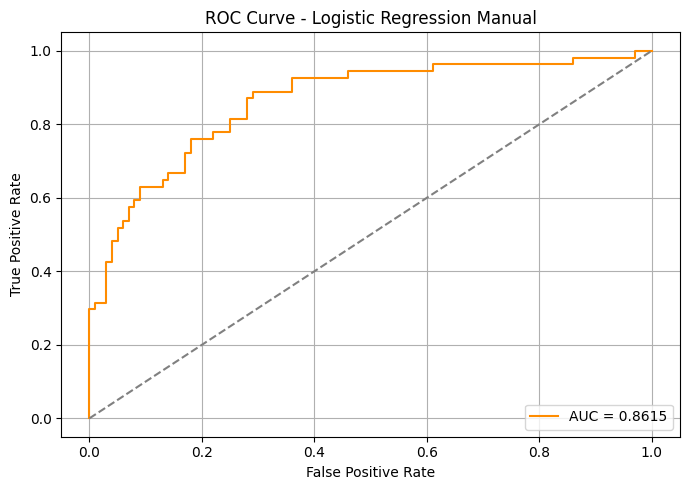

In [198]:
from sklearn.metrics import roc_auc_score, roc_curve

# Hitung ROC AUC
auc = roc_auc_score(y_test, sig_test)
print(f"\nROC AUC Score: {auc:.4f}")

# Hitung titik-titik ROC
fpr, tpr, thresholds = roc_curve(y_test, sig_test)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Manual")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# KNN

## EUC

k = 1, akurasi = 0.7403
k = 2, akurasi = 0.7403
k = 3, akurasi = 0.7662
k = 4, akurasi = 0.7532
k = 5, akurasi = 0.7987
k = 6, akurasi = 0.7727
k = 7, akurasi = 0.8052
k = 8, akurasi = 0.7922
k = 9, akurasi = 0.8247
k = 10, akurasi = 0.7922
k = 11, akurasi = 0.8052
k = 12, akurasi = 0.7922
k = 13, akurasi = 0.7792
k = 14, akurasi = 0.7792
k = 15, akurasi = 0.7857
k = 16, akurasi = 0.7922
k = 17, akurasi = 0.7922
k = 18, akurasi = 0.7857
k = 19, akurasi = 0.7857
k = 20, akurasi = 0.7727
k = 21, akurasi = 0.7792
k = 22, akurasi = 0.7727
k = 23, akurasi = 0.7857
k = 24, akurasi = 0.8117
k = 25, akurasi = 0.8052
k = 26, akurasi = 0.8117
k = 27, akurasi = 0.7987
k = 28, akurasi = 0.8182
k = 29, akurasi = 0.8117
k = 30, akurasi = 0.8182
k = 31, akurasi = 0.8117
k = 32, akurasi = 0.8182
k = 33, akurasi = 0.8052
k = 34, akurasi = 0.7987
k = 35, akurasi = 0.7987
k = 36, akurasi = 0.8052
k = 37, akurasi = 0.7987
k = 38, akurasi = 0.8117
k = 39, akurasi = 0.7987
k = 40, akurasi = 0.8117
k = 41, a

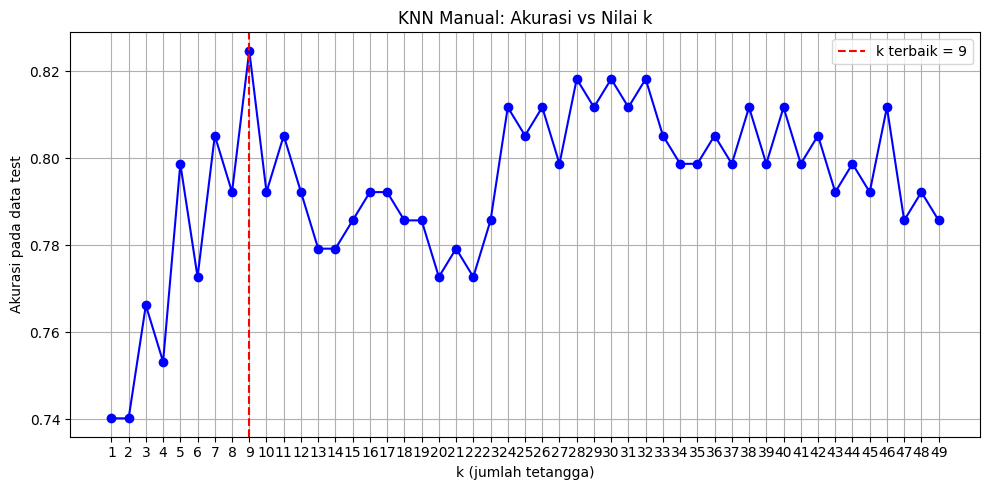

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# STEP 1: Siapkan data
df_copy = df.copy()
X = df_copy.drop(columns=['BloodPressure','Outcome']).values
y = df_copy['Outcome'].values

# STEP 2: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=22, stratify=y)


# STEP 4: KNN Manual Function
def classify_point(X, y, p, k=5):
    distances = []
    for xi, yi in zip(X, y):
        dist = np.linalg.norm(xi - p)
        distances.append((dist, yi))
    distances = sorted(distances, key=lambda x: x[0])[:k]
    labels = [label for _, label in distances]
    return Counter(labels).most_common(1)[0][0]

def classify_point_prob(X, y, p, k=5):
    distances = []
    for xi, yi in zip(X, y):
        dist = np.linalg.norm(xi - p)
        distances.append((dist, yi))
    distances = sorted(distances, key=lambda x: x[0])[:k]
    labels = [label for _, label in distances]
    
    # Probabilitas = proporsi class 1
    return sum(labels) / k


# STEP 5: Loop untuk berbagai nilai k
accuracies = []
k_values = range(1, 50)  # coba dari k = 1 sampai 30

for k in k_values:
    y_pred_test = np.array([classify_point(X_train, y_train, xi, k) for xi in X_test])
    acc = accuracy_score(y_test, y_pred_test)
    accuracies.append(acc)
    print(f'k = {k}, akurasi = {acc:.4f}')

# STEP 6: Cari k terbaik
best_k = k_values[np.argmax(accuracies)]
print(f'\n🔍 K terbaik: {best_k} dengan akurasi = {max(accuracies):.4f}')

# STEP 7: Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='blue')
plt.title("KNN Manual: Akurasi vs Nilai k")
plt.xlabel("k (jumlah tetangga)")
plt.ylabel("Akurasi pada data test")
plt.xticks(k_values)
plt.grid(True)
plt.axvline(best_k, color='red', linestyle='--', label=f'k terbaik = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()


In [200]:
y_test

array([0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1])


=== Classification Report (k terbaik) ===
              precision    recall  f1-score   support

           0     0.8288    0.9200    0.8720       100
           1     0.8140    0.6481    0.7216        54

    accuracy                         0.8247       154
   macro avg     0.8214    0.7841    0.7968       154
weighted avg     0.8236    0.8247    0.8193       154



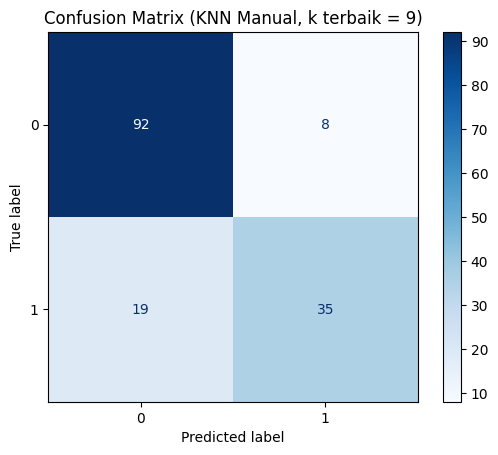

In [201]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# STEP 8: Evaluasi ulang dengan k terbaik
y_pred_best = np.array([classify_point(X_train, y_train, xi, best_k) for xi in X_test])

print("\n=== Classification Report (k terbaik) ===")
print(classification_report(y_test, y_pred_best, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (KNN Manual, k terbaik = {best_k})')
plt.grid(False)
plt.show()


ROC AUC (k=9): 0.8547


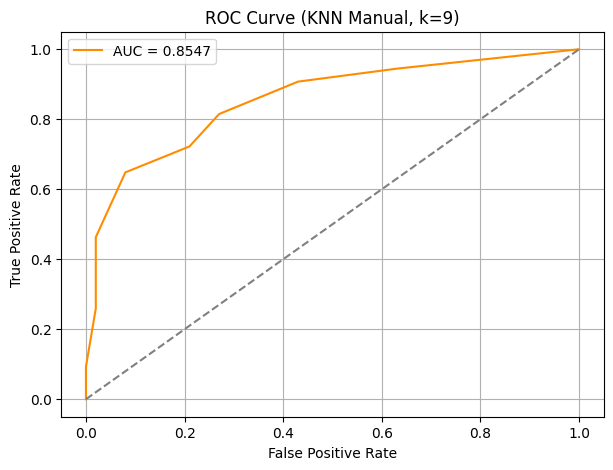

In [202]:
from sklearn.metrics import roc_auc_score, roc_curve

# Prediksi probabilitas class 1 untuk test set
y_prob = np.array([classify_point_prob(X_train, y_train, xi, best_k) for xi in X_test])

# ROC AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC (k={best_k}): {auc_score:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (KNN Manual, k={best_k})")
plt.legend()
plt.grid(True)
plt.show()


## Manha

k = 1, akurasi = 0.7338
k = 2, akurasi = 0.7338
k = 3, akurasi = 0.7922
k = 4, akurasi = 0.7727
k = 5, akurasi = 0.7922
k = 6, akurasi = 0.7727
k = 7, akurasi = 0.7987
k = 8, akurasi = 0.7857
k = 9, akurasi = 0.7727
k = 10, akurasi = 0.7532
k = 11, akurasi = 0.7857
k = 12, akurasi = 0.7922
k = 13, akurasi = 0.7922
k = 14, akurasi = 0.7857
k = 15, akurasi = 0.8117
k = 16, akurasi = 0.8117
k = 17, akurasi = 0.8182
k = 18, akurasi = 0.8117
k = 19, akurasi = 0.8182
k = 20, akurasi = 0.8117
k = 21, akurasi = 0.7857
k = 22, akurasi = 0.7987
k = 23, akurasi = 0.7857
k = 24, akurasi = 0.7922
k = 25, akurasi = 0.7922
k = 26, akurasi = 0.7922
k = 27, akurasi = 0.7987
k = 28, akurasi = 0.7987
k = 29, akurasi = 0.8182
k = 30, akurasi = 0.8182
k = 31, akurasi = 0.8052
k = 32, akurasi = 0.8182
k = 33, akurasi = 0.8052
k = 34, akurasi = 0.8117
k = 35, akurasi = 0.8052
k = 36, akurasi = 0.8117
k = 37, akurasi = 0.8117
k = 38, akurasi = 0.8182
k = 39, akurasi = 0.8117
k = 40, akurasi = 0.8117
k = 41, a

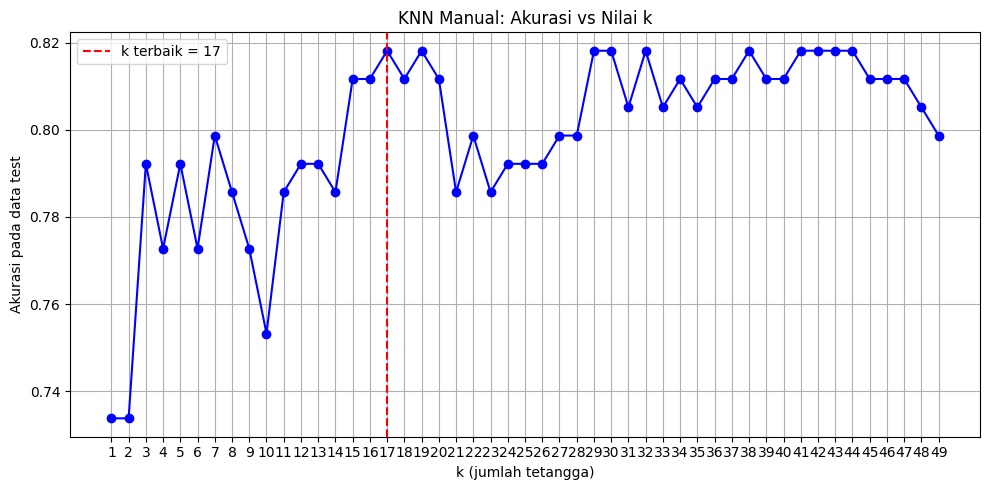

In [203]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# STEP 1: Siapkan data
df_copy = df.copy()
X = df_copy.drop(columns=['BloodPressure','Outcome']).values
y = df_copy['Outcome'].values

# STEP 2: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=22, stratify=y)


# STEP 4: KNN Manual Function
def classify_point(X, y, p, k=5):
    distances = []
    for xi, yi in zip(X, y):
        dist = np.sum(np.abs(xi - p))  # Manhattan Distance
        distances.append((dist, yi))
    distances = sorted(distances, key=lambda x: x[0])[:k]
    labels = [label for _, label in distances]
    return Counter(labels).most_common(1)[0][0]

def classify_point_prob(X, y, p, k=5):
    distances = []
    for xi, yi in zip(X, y):
        dist = np.sum(np.abs(xi - p))  # Manhattan Distance
        distances.append((dist, yi))
    distances = sorted(distances, key=lambda x: x[0])[:k]
    labels = [label for _, label in distances]
    
    # Probabilitas = proporsi class 1
    return sum(labels) / k


# STEP 5: Loop untuk berbagai nilai k
accuracies = []
k_values = range(1, 50)  # coba dari k = 1 sampai 30

for k in k_values:
    y_pred_test = np.array([classify_point(X_train, y_train, xi, k) for xi in X_test])
    acc = accuracy_score(y_test, y_pred_test)
    accuracies.append(acc)
    print(f'k = {k}, akurasi = {acc:.4f}')

# STEP 6: Cari k terbaikw
best_k = k_values[np.argmax(accuracies)]
print(f'\n🔍 K terbaik: {best_k} dengan akurasi = {max(accuracies):.4f}')

# STEP 7: Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='blue')
plt.title("KNN Manual: Akurasi vs Nilai k")
plt.xlabel("k (jumlah tetangga)")
plt.ylabel("Akurasi pada data test")
plt.xticks(k_values)
plt.grid(True)
plt.axvline(best_k, color='red', linestyle='--', label=f'k terbaik = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()



=== Classification Report (k terbaik) ===
              precision    recall  f1-score   support

           0     0.8103    0.9400    0.8704       100
           1     0.8421    0.5926    0.6957        54

    accuracy                         0.8182       154
   macro avg     0.8262    0.7663    0.7830       154
weighted avg     0.8215    0.8182    0.8091       154



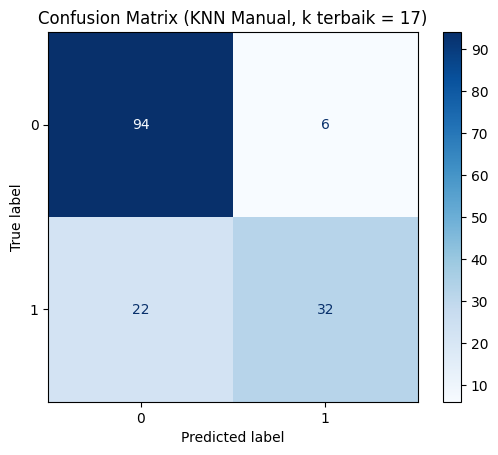

In [204]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# STEP 8: Evaluasi ulang dengan k terbaik
y_pred_best = np.array([classify_point(X_train, y_train, xi, best_k) for xi in X_test])

print("\n=== Classification Report (k terbaik) ===")
print(classification_report(y_test, y_pred_best, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (KNN Manual, k terbaik = {best_k})')
plt.grid(False)
plt.show()


ROC AUC (k=17): 0.8702


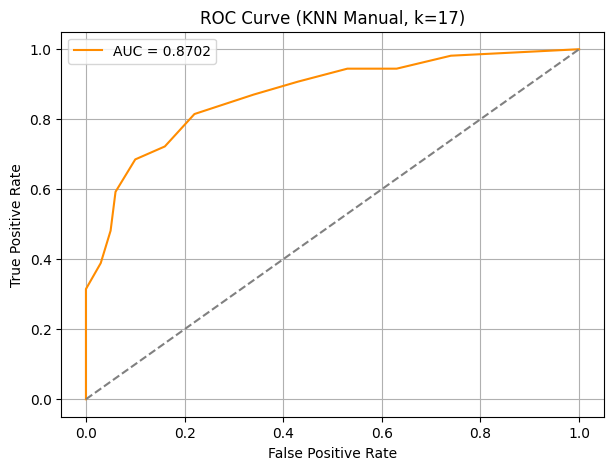

In [205]:
from sklearn.metrics import roc_auc_score, roc_curve

# Prediksi probabilitas class 1 untuk test set
y_prob = np.array([classify_point_prob(X_train, y_train, xi, best_k) for xi in X_test])

# ROC AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC AUC (k={best_k}): {auc_score:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (KNN Manual, k={best_k})")
plt.legend()
plt.grid(True)
plt.show()


# KMEANS

In [235]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Simpan label aktual
labels_aktual = df['Outcome']

# Drop label dari fitur
X = df.drop(columns=['Outcome'])

# Normalisasi fitur
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [240]:
from sklearn.cluster import KMeans

# Jalankan KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
labels_pred = kmeans.labels_
# Jika cluster 0 ternyata cocok dengan label 1, kita balik
labels_pred_fix = 1 - labels_pred



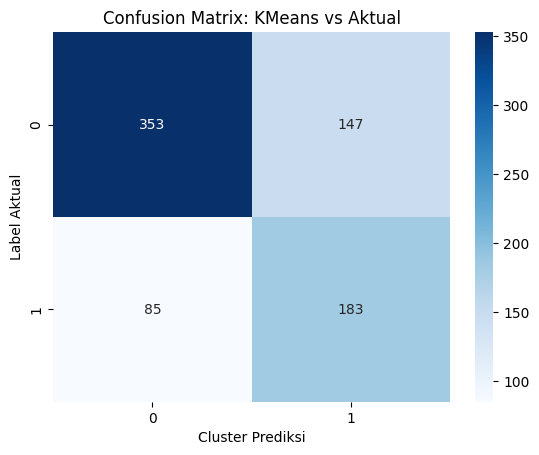

Akurasi KMeans (Cluster 0=Label 0): 0.70
Akurasi KMeans (Cluster 0=Label 1): 0.30


In [241]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(labels_aktual, labels_pred_fix)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Cluster Prediksi")
plt.ylabel("Label Aktual")
plt.title("Confusion Matrix: KMeans vs Aktual")
plt.show()

# Karena cluster bisa tertukar (0 ↔ 1), kita cek dua kemungkinan akurasi
acc1 = accuracy_score(labels_aktual, labels_pred_fix)
acc2 = accuracy_score(labels_aktual, 1 - labels_pred_fix)
print(f"Akurasi KMeans (Cluster 0=Label 0): {acc1:.2f}")
print(f"Akurasi KMeans (Cluster 0=Label 1): {acc2:.2f}")


In [246]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(labels_aktual, labels_pred_fix)
precision = precision_score(labels_aktual, labels_pred_fix)
recall = recall_score(labels_aktual, labels_pred_fix)
f1 = f1_score(labels_aktual, labels_pred_fix)

print(f"Akurasi : {accuracy:.2f}")
print(f"Presisi : {precision:.2f}")
print(f"Recall  : {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Akurasi : 0.70
Presisi : 0.55
Recall  : 0.68
F1 Score: 0.61


In [242]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels_pred)
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.17


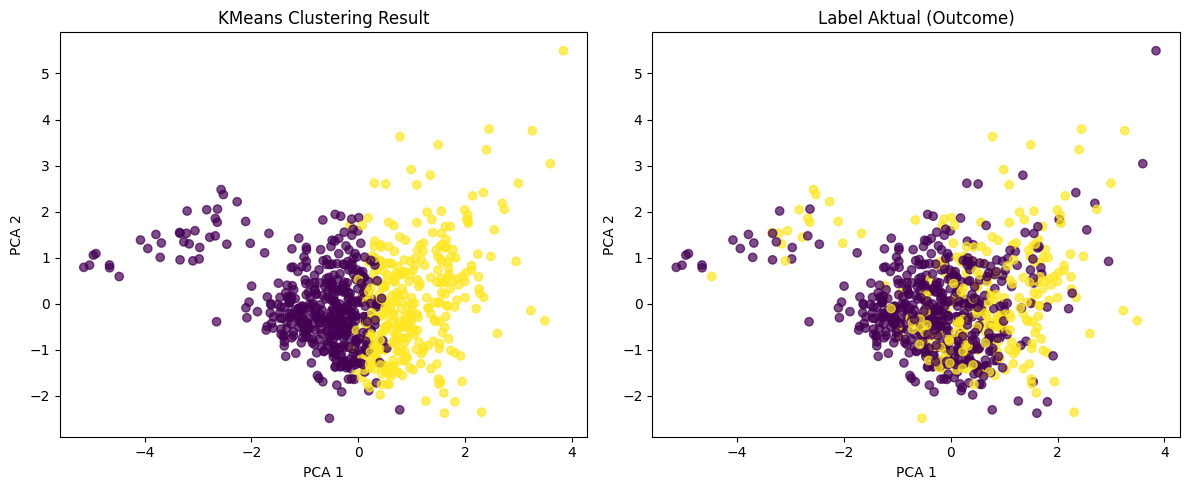

In [244]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduksi dimensi ke 2D untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi hasil cluster KMeans
plt.figure(figsize=(12, 5))

# Plot berdasarkan hasil cluster
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pred_fix, cmap='viridis', alpha=0.7)
plt.title('KMeans Clustering Result')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Plot berdasarkan label aktual
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_aktual, cmap='viridis', alpha=0.7)
plt.title('Label Aktual (Outcome)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.tight_layout()
plt.show()


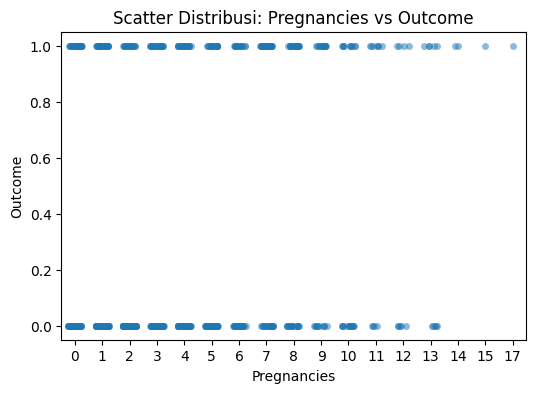

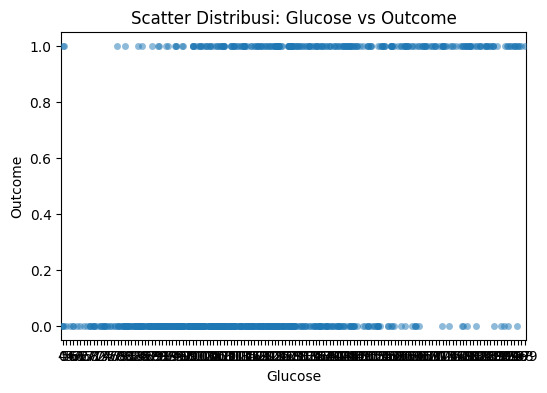

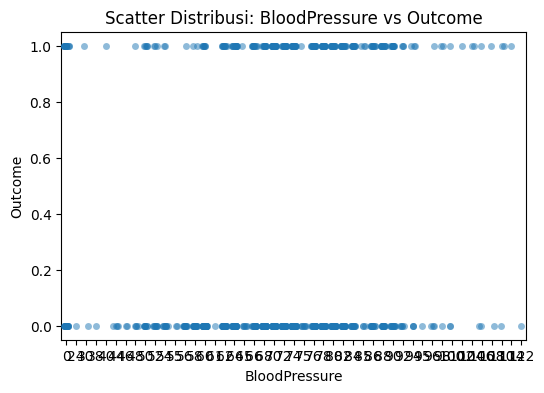

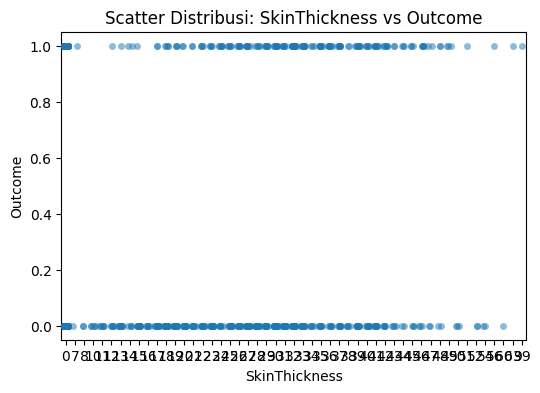

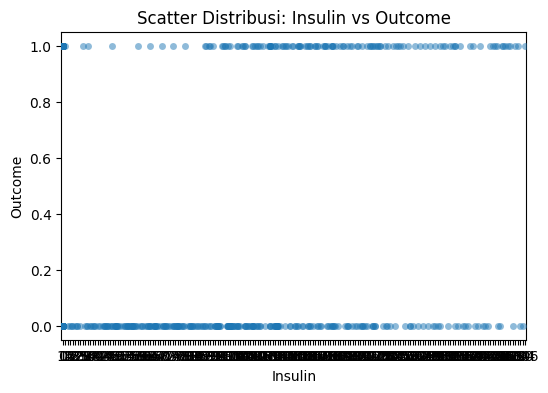

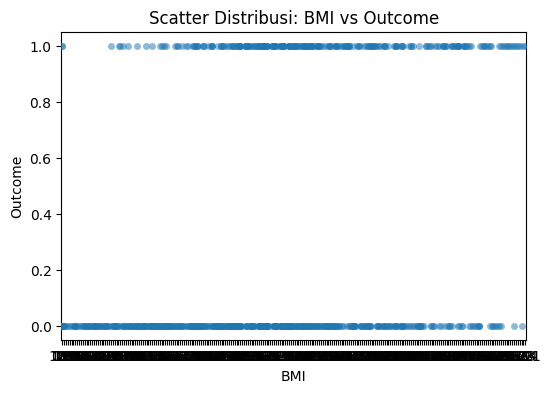

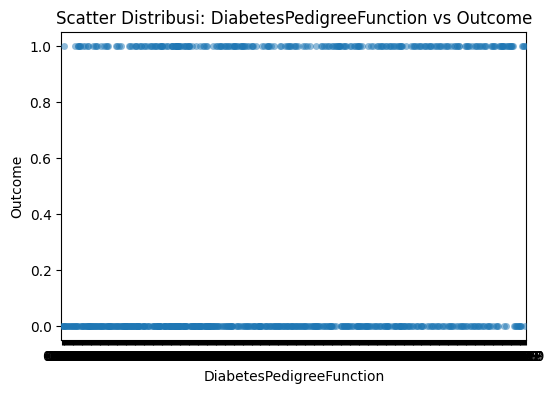

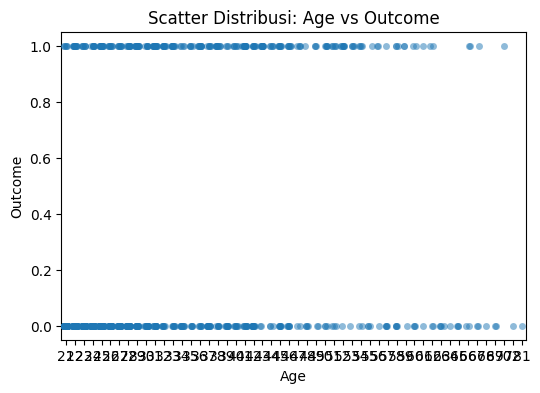

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerik_cols = df.select_dtypes(include='number').columns.drop('Outcome')  # sesuaikan kalau nama target beda

for col in numerik_cols:
    plt.figure(figsize=(6, 4))
    sns.stripplot(x=df[col], y=df['Outcome'], jitter=0.25, alpha=0.5)
    plt.title(f'Scatter Distribusi: {col} vs Outcome')
    plt.xlabel(col)
    plt.ylabel('Outcome')
    plt.show()


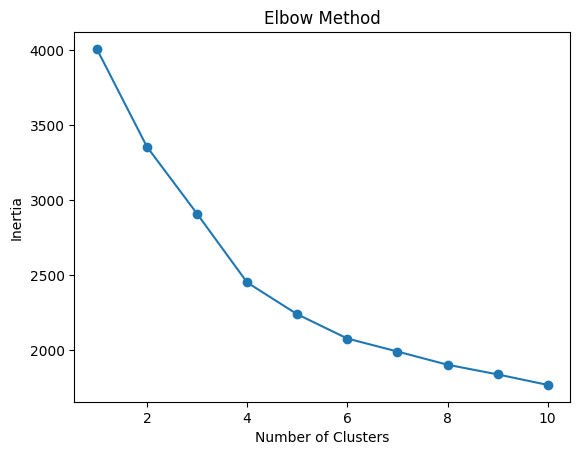

In [247]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()
